# Combined EDA: PhishTank & Tranco
Exploratory data analysis on two datasets used in our phishing-detection pipeline:
1. **PhishTank** — verified phishing URLs (`../data/raw_input/verified_online.csv`)
2. **Tranco Top 1 M** — legitimate, popularity-ranked domains (`../data/raw_input/top-1m.csv`)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from urllib.parse import urlparse

---
# PhishTank — Verified Phishing URLs
This section analyses the PhishTank *verified-online* feed, a curated list of confirmed phishing URLs.  
The dataset captures full URLs (scheme + host + path) along with the targeted brand and current online/offline status. [11] 
**Date accessed:** 03/05/2026

In [2]:
phish = pd.read_csv('../data/raw_input/verified_online.csv')
phish['target'] = phish['target'].str.replace('&amp;', '&', regex=False)
phish.head()

,phish_id,url,phish_detail_url,submission_time,verified,verification_time,online,target
0,9358496,https://sgpass-fr033.com/,http://www.phishtank.com/phish_detail.php?phis...,2026-03-03T19:50:49+00:00,yes,2026-03-03T20:12:24+00:00,yes,Other
1,9358495,https://sgpass-fr033.com/pages/asset.php,http://www.phishtank.com/phish_detail.php?phis...,2026-03-03T19:50:36+00:00,yes,2026-03-03T20:12:24+00:00,yes,Other
2,9358485,https://dervi-emprend-ec.webcindario.com/,http://www.phishtank.com/phish_detail.php?phis...,2026-03-03T19:27:05+00:00,yes,2026-03-03T19:32:43+00:00,yes,Other
3,9358483,https://allegro.pl-oferta1081410.sbs,http://www.phishtank.com/phish_detail.php?phis...,2026-03-03T19:23:57+00:00,yes,2026-03-03T19:32:43+00:00,yes,Allegro
4,9358482,http://allegrolokalnie.oferta362639327346393.sbs,http://www.phishtank.com/phish_detail.php?phis...,2026-03-03T19:23:42+00:00,yes,2026-03-03T19:32:43+00:00,yes,Allegro


In [3]:
phish.shape

(56045, 8)

In [4]:
phish['submission_time'] = pd.to_datetime(phish['submission_time'])
phish['verification_time'] = pd.to_datetime(phish['verification_time'])
phish.dtypes

phish_id                           int64
url                               object
phish_detail_url                  object
submission_time      datetime64[ns, UTC]
verified                          object
verification_time    datetime64[ns, UTC]
online                            object
target                            object
dtype: object

## Null / Missing Value Analysis

In [5]:
phish.isnull().sum()

phish_id             0
url                  0
phish_detail_url     0
submission_time      0
verified             0
verification_time    0
online               0
target               0
dtype: int64

In [6]:
(phish == '').sum()

phish_id             0
url                  0
phish_detail_url     0
submission_time      0
verified             0
verification_time    0
online               0
target               0
dtype: int64

## Target Brand Distribution

In [7]:
target_counts = phish['target'].value_counts().head(15)
print(target_counts)

target
Other                                  52773
Internal Revenue Service                 814
Allegro                                  654
Facebook                                 319
Microsoft                                185
Optus                                    147
DHL                                      102
AT&T                                      77
Sumitomo Mitsui Banking Corporation       75
Amazon.com                                67
Bradesco                                  62
Netflix                                   61
PayPal                                    57
Adobe                                     47
eBay, Inc.                                41
Name: count, dtype: int64


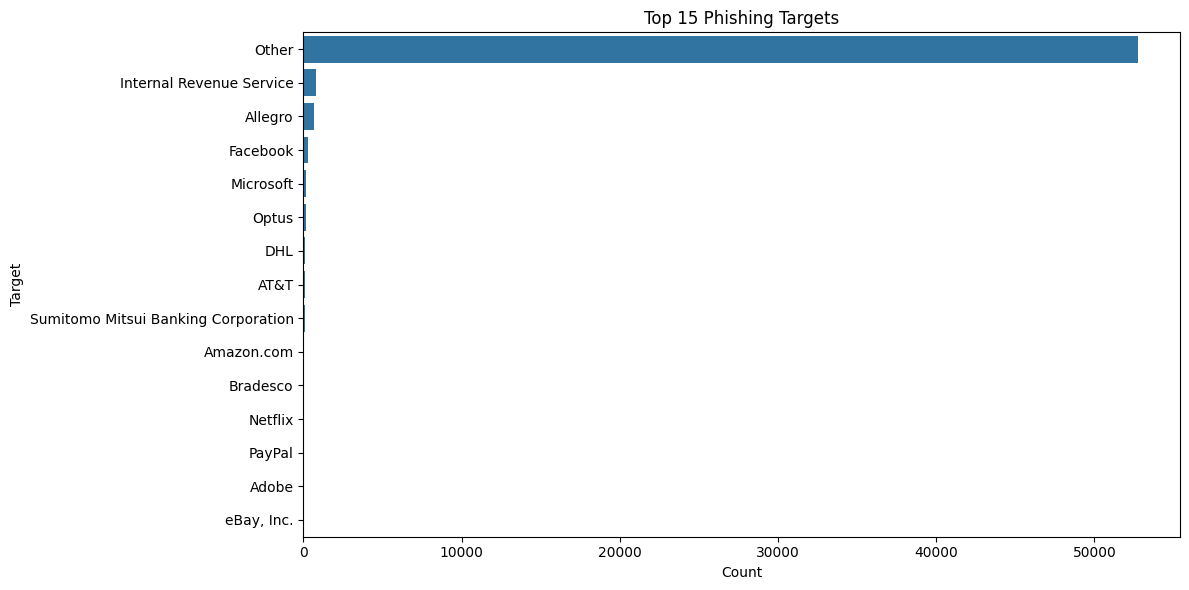

In [8]:
plt.figure(figsize=(12,6))
sns.barplot(x=target_counts.values, y=target_counts.index)
plt.title('Top 15 Phishing Targets')
plt.xlabel('Count')
plt.ylabel('Target')
plt.tight_layout()
plt.show()

* "Other" accounts for the vast majority of targets. "Other" is excluded in the below chart but note this represents a small fraction of the full dataset.

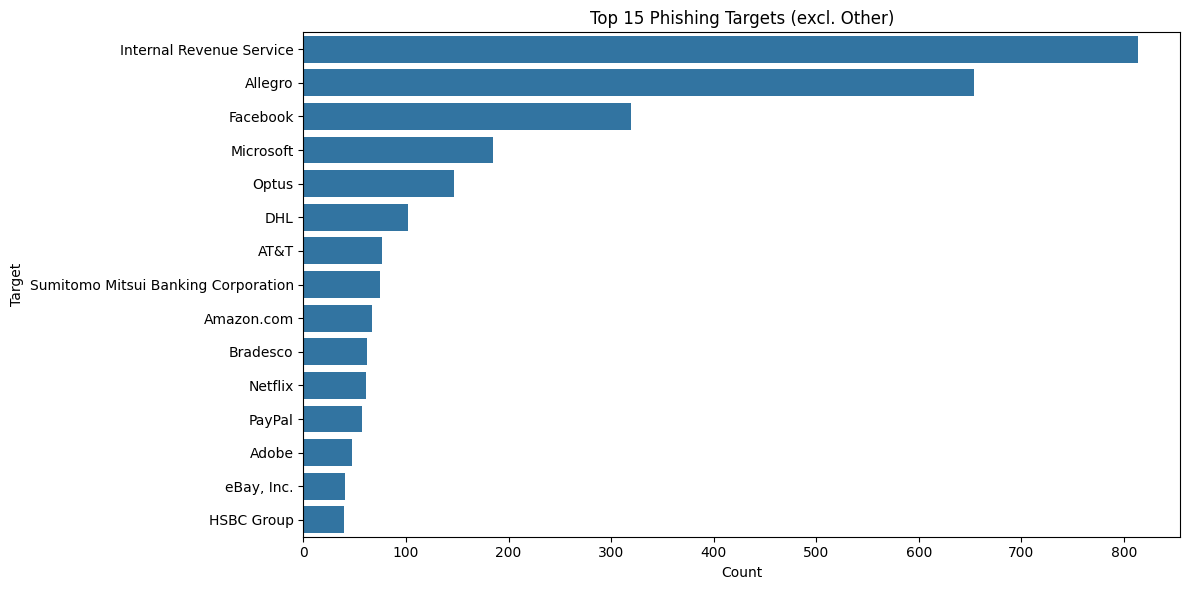

In [9]:
target_counts_filtered = phish[phish['target'] != 'Other']['target'].value_counts().head(15)
plt.figure(figsize=(12,6))
sns.barplot(x=target_counts_filtered.values, y=target_counts_filtered.index)
plt.title('Top 15 Phishing Targets (excl. Other)')
plt.xlabel('Count')
plt.ylabel('Target')
plt.tight_layout()
plt.show()

## Online vs Offline Breakdown

online
yes    56045
Name: count, dtype: int64


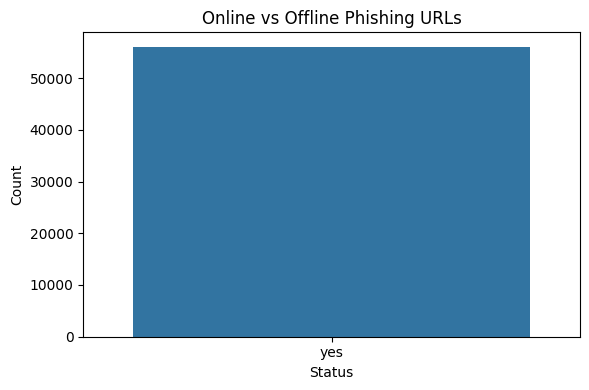

In [10]:
online_counts = phish['online'].value_counts()
print(online_counts)

plt.figure(figsize=(6,4))
sns.barplot(x=online_counts.index, y=online_counts.values)
plt.title('Online vs Offline Phishing URLs')
plt.xlabel('Status')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Dataset Limitations
This dataset is only the verified online feed, meaning this dataset is a subset of the greater PhishTank dataset. Future work could expand to use the full dataset. This dataset would be great for clustering/unsupervised ML work: the dominance of 'Other' in the target category shows the opportunity to clean/mine this data for meaningful categorization.

## URL Structure Analysis
Feature engineering and visualizations on URL structure — length, hosting domains, path depth, and character composition.

In [11]:
phish['host'] = phish['url'].apply(lambda x: urlparse(x).netloc.lower())
phish['full_length'] = phish['url'].str.len()
phish['host_length'] = phish['host'].str.len()
phish['path'] = phish['url'].apply(lambda x: urlparse(x).path)
phish['path_depth'] = phish['path'].apply(lambda p: p.strip('/').count('/') + 1 if p.strip('/') else 0)
phish['has_path'] = (phish['path'].str.strip('/') != '').astype(int)
phish['tld_ext'] = phish['host'].str.rsplit('.', n=1).str[-1]
phish['dot_count'] = phish['url'].str.count(r'\.')
phish['hyphen_count'] = phish['url'].str.count('-')
phish['digit_count'] = phish['url'].str.count(r'\d')
phish['digit_ratio'] = phish['digit_count'] / phish['full_length']
phish['subdomain_depth'] = phish['host'].str.count(r'\.')

phish[['full_length', 'host_length', 'path_depth', 'dot_count', 'hyphen_count',
    'digit_count', 'digit_ratio', 'subdomain_depth']].describe()

,full_length,host_length,path_depth,dot_count,hyphen_count,digit_count,digit_ratio,subdomain_depth
count,56045.000000,56045.000000,56045.000000,56045.000000,56045.000000,56045.000000,56045.000000,56045.000000
mean,60.922866,19.275511,1.387457,1.974413,0.797127,6.373254,0.075019,1.768454
std,166.386061,12.977728,1.582218,1.025418,1.391185,24.004548,0.096198,0.583268
min,12.000000,4.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,23.000000,8.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
50%,38.000000,16.000000,1.000000,2.000000,0.000000,1.000000,0.045455,2.000000
75%,62.000000,25.000000,2.000000,2.000000,1.000000,8.000000,0.107143,2.000000
max,25523.000000,147.000000,18.000000,67.000000,50.000000,3413.000000,0.796610,9.000000


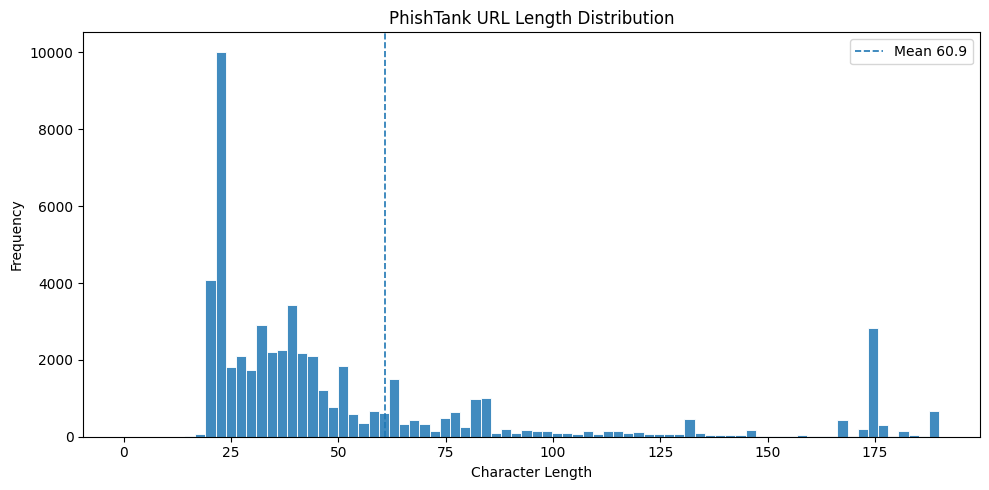

In [45]:
# URL length distribution (clipped to 98th percentile)
plt.figure(figsize=(10, 5))
sns.histplot(phish['full_length'], bins=80, edgecolor='white', alpha=0.85,
             binrange=(0, phish['full_length'].quantile(0.98)))
plt.axvline(phish['full_length'].mean(), ls='--', lw=1.2,
            label=f'Mean {phish["full_length"].mean():.1f}')
plt.title('PhishTank URL Length Distribution')
plt.xlabel('Character Length')
plt.ylabel('Frequency')
plt.tight_layout()
plt.legend()
plt.show()

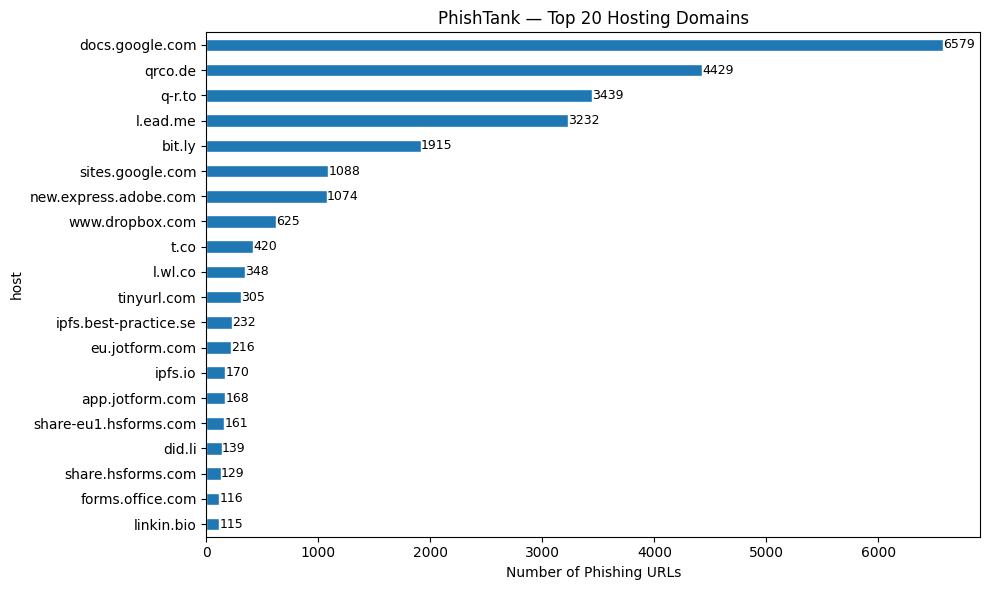

In [42]:
# Top 20 hosting domains
host_counts = phish['host'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 6))
host_counts.plot.barh(ax=ax, edgecolor='white')
ax.set_title('PhishTank — Top 20 Hosting Domains')
ax.set_xlabel('Number of Phishing URLs')
ax.invert_yaxis()

for i, v in enumerate(host_counts):
    ax.text(v + 1, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.show()

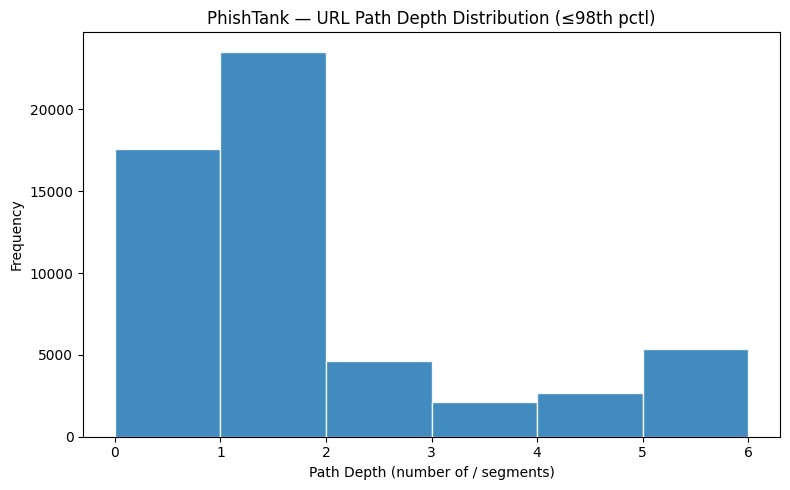

In [41]:
# Path depth distribution (clipped to 98th percentile)
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(phish['path_depth'],
        bins=range(0, int(phish['path_depth'].quantile(0.98)) + 2),
        edgecolor='white', alpha=0.85)
ax.set_title('PhishTank — URL Path Depth Distribution (≤98th pctl)')
ax.set_xlabel('Path Depth (number of / segments)')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

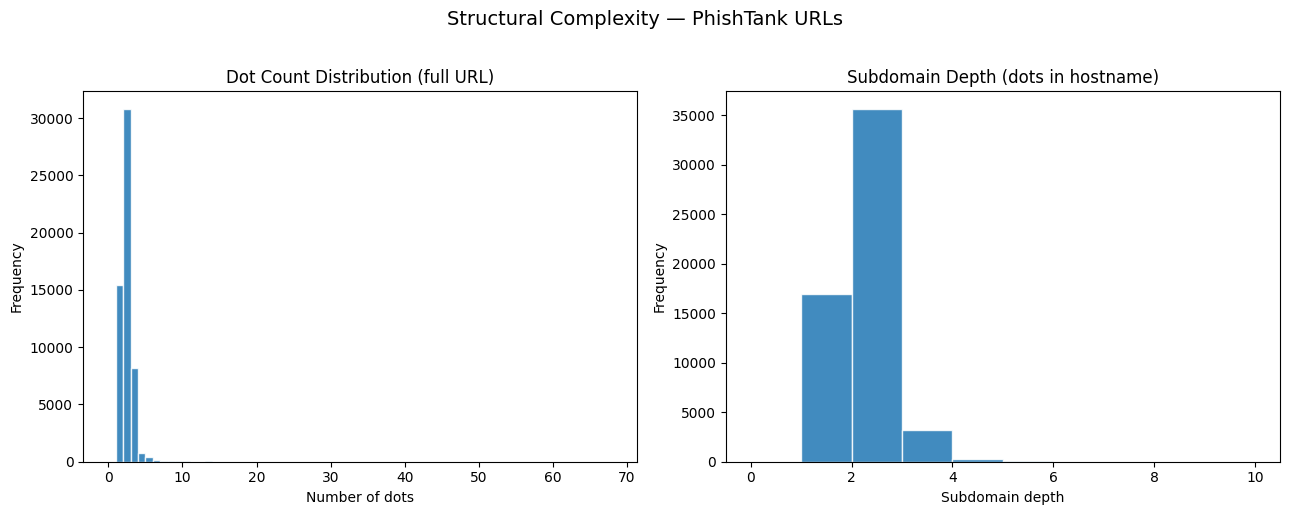

In [39]:
# Structural complexity: dot count & subdomain depth
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(phish['dot_count'], bins=range(0, phish['dot_count'].max() + 2),
             edgecolor='white', alpha=0.85)
axes[0].set_title('Dot Count Distribution (full URL)')
axes[0].set_xlabel('Number of dots')
axes[0].set_ylabel('Frequency')

axes[1].hist(phish['subdomain_depth'], bins=range(0, phish['subdomain_depth'].max() + 2),
             edgecolor='white', alpha=0.85)
axes[1].set_title('Subdomain Depth (dots in hostname)')
axes[1].set_xlabel('Subdomain depth')
axes[1].set_ylabel('Frequency')

fig.suptitle('Structural Complexity — PhishTank URLs', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

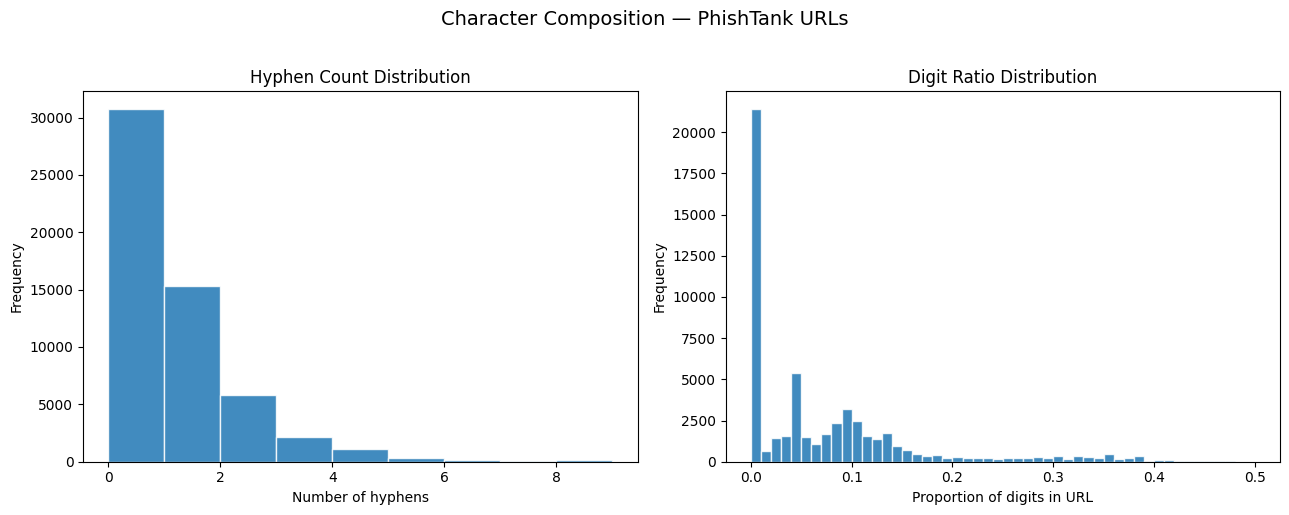

In [38]:
# Character composition: hyphens & digit ratio
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(phish['hyphen_count'], bins=range(0, 10),
             edgecolor='white', alpha=0.85)
axes[0].set_title('Hyphen Count Distribution')
axes[0].set_xlabel('Number of hyphens')
axes[0].set_ylabel('Frequency')

axes[1].hist(phish['digit_ratio'], bins=50,
              edgecolor='white', alpha=0.85, range=(0, 0.5))
axes[1].set_title('Digit Ratio Distribution')
axes[1].set_xlabel('Proportion of digits in URL')
axes[1].set_ylabel('Frequency')

fig.suptitle('Character Composition — PhishTank URLs', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
# Tranco — Top 1 M Legitimate Domains
This section analyses the Tranco Top-1M ranking, an aggregated popularity list of legitimate domains.  
Unlike PhishTank URLs, Tranco entries are bare domains (no scheme or path), making structural features directly comparable at the hostname level.
Cisco provides resources to help massage all the data coming in [10].

**List ID:** 6GPNX &nbsp;|&nbsp; **Date accessed:** 03/05/2026

In [17]:
tranco = pd.read_csv('../data/raw_input/top-1m.csv', header=None, names=['rank', 'domain'])
tranco.head()

,rank,domain
0,1,google.com
1,2,microsoft.com
2,3,gtld-servers.net
3,4,facebook.com
4,5,mail.ru


In [18]:
tranco.shape

(1000000, 2)

In [19]:
tranco.dtypes

rank       int64
domain    object
dtype: object

## Null / Missing Value Analysis

In [20]:
tranco.isnull().sum()

(tranco == '').sum()

rank      0
domain    0
dtype: int64

## Duplicate Check

In [21]:
duplicateDomains = tranco['domain'].duplicated().sum()
duplicateRanks = tranco['rank'].duplicated().sum()
print(f'Duplicate domains: {duplicateDomains}')
print(f'Duplicate ranks: {duplicateRanks}')

Duplicate domains: 0
Duplicate ranks: 0


## TLD Distribution

In [22]:
tranco['tld'] = tranco['domain'].str.split('.').str[-1]
tld_counts = tranco['tld'].value_counts().head(15)
print(tld_counts)

tld
com    431460
net     51741
ru      42879
org     39514
de      26817
uk      22815
br      17524
jp      16280
in      12403
fr      11433
io      10800
nl      10241
it      10051
xyz      9407
pl       9054
Name: count, dtype: int64


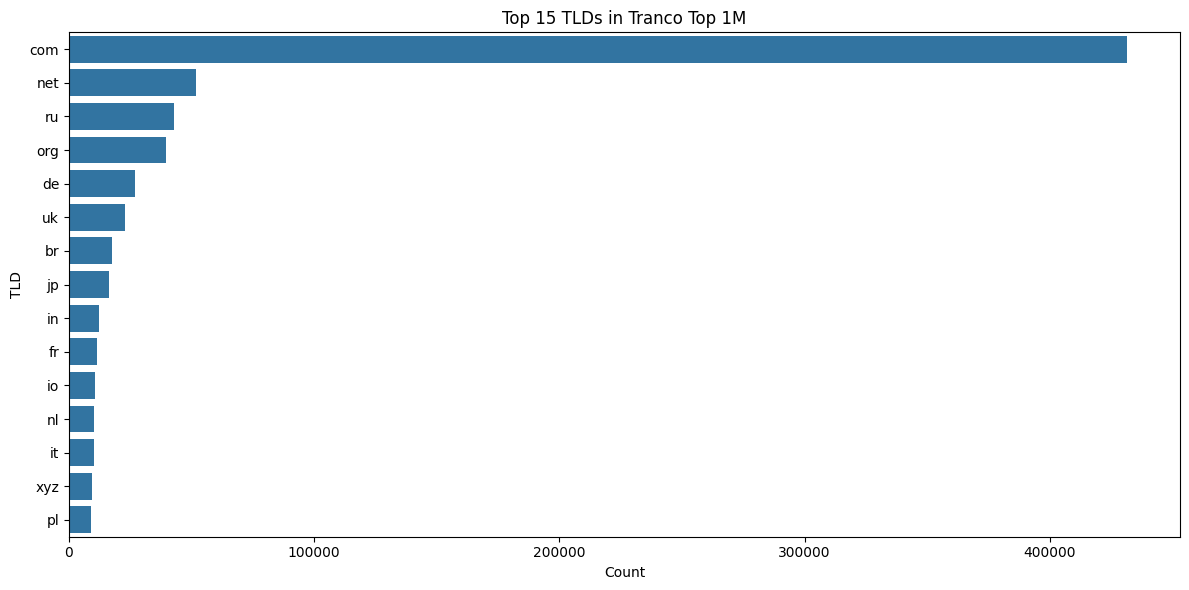

In [23]:
plt.figure(figsize=(12,6))
sns.barplot(x=tld_counts.values, y=tld_counts.index)
plt.title('Top 15 TLDs in Tranco Top 1M')
plt.xlabel('Count')
plt.ylabel('TLD')
plt.tight_layout()
plt.show()

## Domain Length Distribution

In [24]:
tranco['domain_length'] = tranco['domain'].str.len()
print(tranco['domain_length'].describe())

count    1000000.000000
mean          13.739423
std            4.346079
min            4.000000
25%           11.000000
50%           13.000000
75%           16.000000
max           75.000000
Name: domain_length, dtype: float64


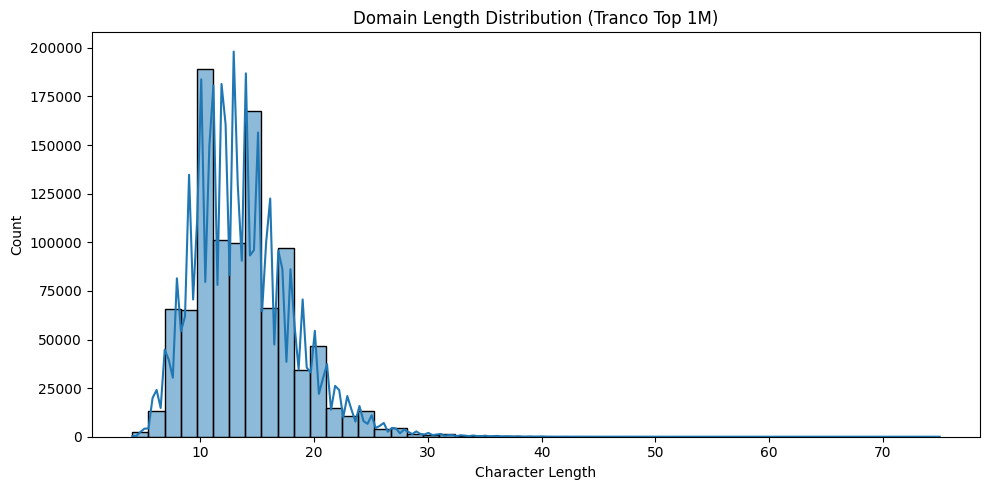

In [25]:
plt.figure(figsize=(10, 5))
sns.histplot(tranco['domain_length'], bins=50, kde=True)
plt.title('Domain Length Distribution (Tranco Top 1M)')
plt.xlabel('Character Length')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Structural & Character Features
Dot counts, subdomain depth, hyphens, and digit ratios for Tranco domains.

In [26]:
tranco['dot_count'] = tranco['domain'].str.count(r'\.')
tranco['hyphen_count'] = tranco['domain'].str.count('-')
tranco['digit_count'] = tranco['domain'].str.count(r'\d')
tranco['digit_ratio'] = tranco['digit_count'] / tranco['domain_length']
tranco['subdomain_depth'] = tranco['domain'].str.count(r'\.')

tranco[['domain_length', 'dot_count', 'hyphen_count', 'digit_count', 'digit_ratio', 'subdomain_depth']].describe()

,domain_length,dot_count,hyphen_count,digit_count,digit_ratio,subdomain_depth
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,13.739423,1.107173,0.121737,0.275257,0.022526,1.107173
std,4.346079,0.314686,0.410282,0.936712,0.075484,0.314686
min,4.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,11.000000,1.000000,0.000000,0.000000,0.000000,1.000000
50%,13.000000,1.000000,0.000000,0.000000,0.000000,1.000000
75%,16.000000,1.000000,0.000000,0.000000,0.000000,1.000000
max,75.000000,3.000000,11.000000,56.000000,0.933333,3.000000


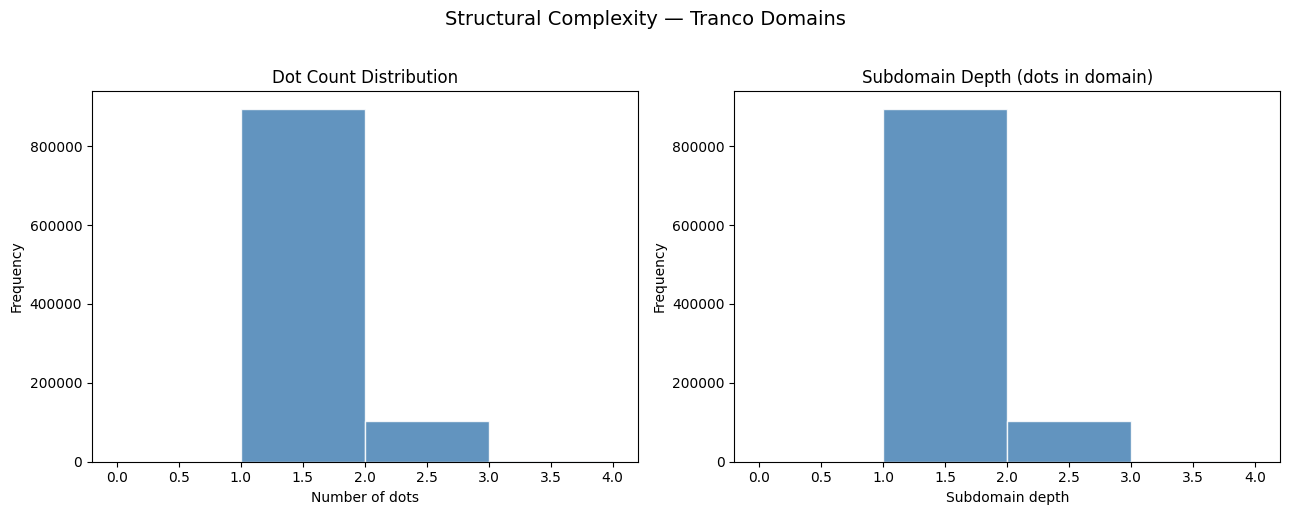

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bins_dots = range(0, tranco['dot_count'].max() + 2)
axes[0].hist(tranco['dot_count'], bins=bins_dots, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Dot Count Distribution')
axes[0].set_xlabel('Number of dots')
axes[0].set_ylabel('Frequency')

bins_sub = range(0, tranco['subdomain_depth'].max() + 2)
axes[1].hist(tranco['subdomain_depth'], bins=bins_sub, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].set_title('Subdomain Depth (dots in domain)')
axes[1].set_xlabel('Subdomain depth')
axes[1].set_ylabel('Frequency')

fig.suptitle('Structural Complexity — Tranco Domains', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

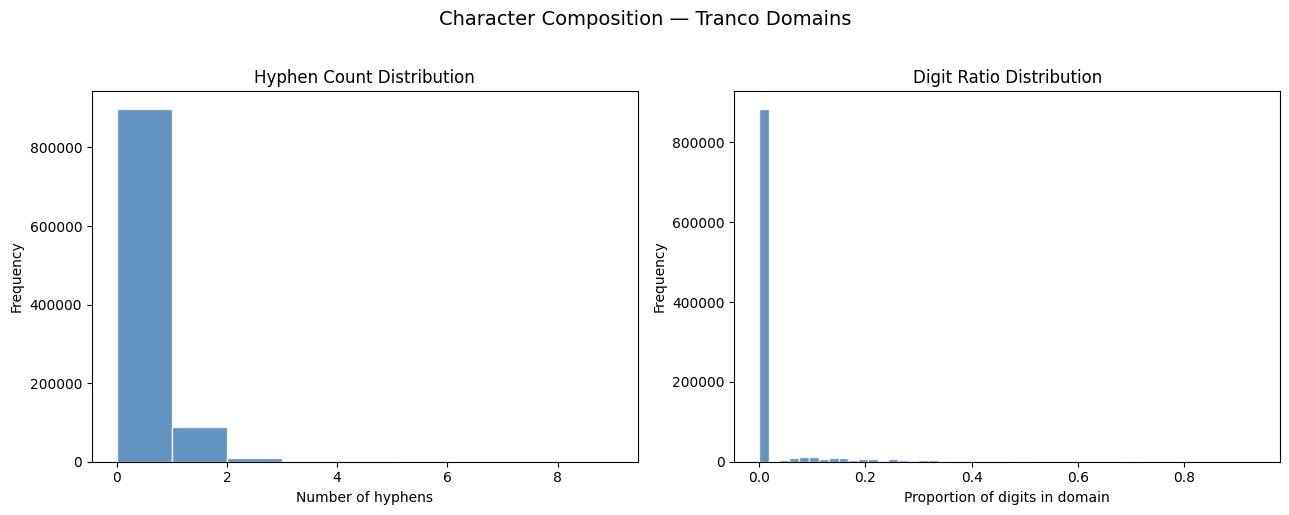

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(tranco['hyphen_count'], bins=range(0, 10), color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Hyphen Count Distribution')
axes[0].set_xlabel('Number of hyphens')
axes[0].set_ylabel('Frequency')

axes[1].hist(tranco['digit_ratio'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].set_title('Digit Ratio Distribution')
axes[1].set_xlabel('Proportion of digits in domain')
axes[1].set_ylabel('Frequency')

fig.suptitle('Character Composition — Tranco Domains', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
# Cross-Dataset Analysis

## PhishTank / Tranco Overlap

In [29]:
phish['domain'] = phish['url'].apply(lambda x:
    urlparse(x).netloc.lower().replace('www.', '', 1))

tranco_domains = set(tranco['domain'].str.lower())
overlap = phish['domain'].isin(tranco_domains).sum()
print(f'Phishing URLs whose domain appears in Tranco Top 1M: {overlap} / {len(phish)} ({overlap/len(phish)*100:.2f}%)')

Phishing URLs whose domain appears in Tranco Top 1M: 13662 / 56045 (24.38%)


In [36]:
print(f"Tranco: {len(tranco):,} legitimate domains (ranked by popularity)")
print(f"PhishTank: {len(phish):,} verified phishing URLs")
print(f"Overlap: {overlap:,} phishing domains found in Tranco top 1M ({overlap/len(phish)*100:.2f}%)")
print("\nNotes:\n- Tranco aggregates multiple blocklists/popularity sources; high rank != guaranteed safe\n- PhishTank is a snapshot of verified-online phishing URLs, not exhaustive\n- Overlap may reflect compromised legitimate domains or shared hosting infrastructure")


Tranco: 1,000,000 legitimate domains (ranked by popularity)
PhishTank: 56,045 verified phishing URLs
Overlap: 13,662 phishing domains found in Tranco top 1M (24.38%)

Notes:
- Tranco aggregates multiple blocklists/popularity sources; high rank != guaranteed safe
- PhishTank is a snapshot of verified-online phishing URLs, not exhaustive
- Overlap may reflect compromised legitimate domains or shared hosting infrastructure


## Summary Comparison Table
Side-by-side comparison of Tranco legitimate domains vs PhishTank phishing URLs.

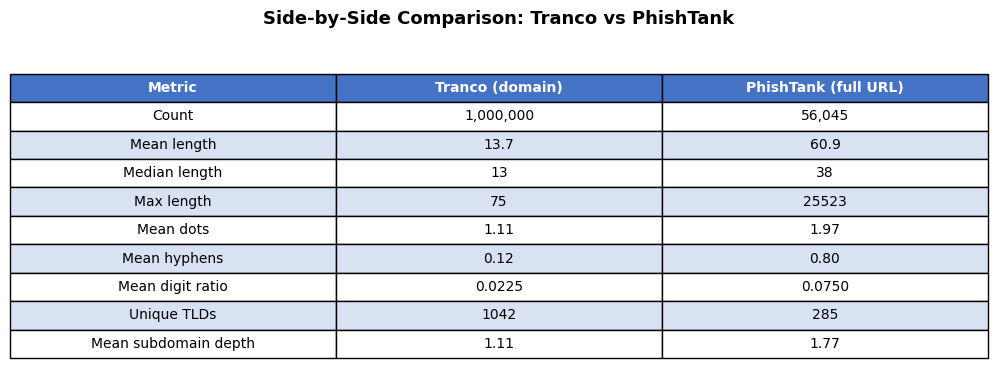

In [35]:
summary_data = {
    "Metric": [
        "Count", "Mean length", "Median length", "Max length",
        "Mean dots", "Mean hyphens", "Mean digit ratio",
        "Unique TLDs", "Mean subdomain depth"
    ],
    "Tranco (domain)": [
        f"{len(tranco):,}",
        f"{tranco['domain_length'].mean():.1f}",
        f"{tranco['domain_length'].median():.0f}",
        f"{tranco['domain_length'].max()}",
        f"{tranco['dot_count'].mean():.2f}",
        f"{tranco['hyphen_count'].mean():.2f}",
        f"{tranco['digit_ratio'].mean():.4f}",
        f"{tranco['tld'].nunique()}",
        f"{tranco['subdomain_depth'].mean():.2f}",
    ],
    "PhishTank (full URL)": [
        f"{len(phish):,}",
        f"{phish['full_length'].mean():.1f}",
        f"{phish['full_length'].median():.0f}",
        f"{phish['full_length'].max()}",
        f"{phish['dot_count'].mean():.2f}",
        f"{phish['hyphen_count'].mean():.2f}",
        f"{phish['digit_ratio'].mean():.4f}",
        f"{phish['tld_ext'].nunique()}",
        f"{phish['subdomain_depth'].mean():.2f}",
    ],
}
summary_tbl = pd.DataFrame(summary_data)

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis("off")
tbl = ax.table(cellText=summary_tbl.values, colLabels=summary_tbl.columns,
               loc="center", cellLoc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.6)
for (row, col), cell in tbl.get_celld().items(): # From Datacamp [9], alternating row colors and header styling
    if row == 0:
        cell.set_facecolor("#4472C4")
        cell.set_text_props(color="white", fontweight="bold")
    elif row % 2 == 0:
        cell.set_facecolor("#D9E2F3")
ax.set_title("Side-by-Side Comparison: Tranco vs PhishTank", fontsize=13,
             fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

## Export Processed Datasets

In [32]:
phish.to_csv('../data/processed_input/phishtank_cleaned.csv', index=False)
tranco.to_csv('../data/processed_input/tranco_cleaned.csv', index=False)
print("Exported phishtank_cleaned.csv and tranco_cleaned.csv.")

Exported phishtank_cleaned.csv and tranco_cleaned.csv.
